In [1]:
user_id = "tp99965073"
domain = "AXISB.COM"
app_name = "Fraud_&_AML"
yarn_queue = "root.DEV.AML_FRAUD_CS"

EXECUTOR_MEMORY=28
EXECUTOR_CORE=4

INITIAL_EXECUTORS=8
MAX_EXECUTORS=50     # 16x4 = 64 cores; lower this to your approved cap if smaller (YARN grants only what is free)
MIN_EXECUTORS=2

In [2]:
import sys
from pyspark.sql import SparkSession, SQLContext
from pyspark import SparkContext, SparkConf
from pyspark.sql import functions as F
from pyspark.sql import Window as W
import pyspark.sql.types as T
from datetime import datetime, date,timedelta
from dateutil.relativedelta import relativedelta
import pandas as pd
import time
import numpy as np


from IPython.core.display import HTML
display(HTML("<style>pre { white-space: pre !important; }</style>"))


# Construct the keytab path and the principal
keytab_path = f"/home/{user_id}@axisb.com/{user_id}.keytab"
principal = f"{user_id}@{domain}"

# Execute the commands
!kdestroy
!kinit -k -t "{keytab_path}" {principal}
try:
    spark.stop()
    print("Existing Spark Session Killed")
except:
    print("")
print("Creating new spark session since: ", datetime.now())
spark = SparkSession\
    .builder\
    .appName(f'JH_{user_id}_{app_name}')\
    .config('spark.sql.execution.arrow.enabled', "true")\
    .config('spark.master','yarn')\
    .config('spark.deploy-mode', 'cluster')\
    .config("spark.principal",f"{user_id}@AXISB.COM") \
    .config("spark.keytab",f"{user_id}.keytab")\
    .config('spark.dynamicAllocation.enabled','true') \
    .config('spark.dynamicAllocation.minExecutors',MIN_EXECUTORS) \
    .config('spark.dynamicAllocation.initialExecutors',INITIAL_EXECUTORS) \
    .config('spark.dynamicAllocation.maxExecutors',MAX_EXECUTORS) \
    .config('spark.executor.cores',EXECUTOR_CORE) \
    .config('spark.dynamicAllocation.executorAllocationRatio','0.8')\
    .config('spark.executor.memory',f'{EXECUTOR_MEMORY}g')\
    .config('spark.driver.memory','16g')\
    .config('spark.driver.cores','1')\
    .config('spark.executor.memoryOverhead','8g')\
    .config('spark.sql.shuffle.partitions','12000')\
    .config('spark.shuffle.service.enabled','true')\
    .config('spark.network.timeout','600s')\
    .config('spark.shuffle.io.maxRetries','10')\
    .config('spark.shuffle.io.retryWait','15s')\
    .config('spark.stage.maxConsecutiveAttempts','8')\
    .config('spark.maxRemoteBlockSizeFetchToMem','512m')\
    .config("spark.sql.broadcastTimeout", "-1")\
    .config("spark.sql.parquet.int96RebaseModeInRead", "LEGACY")\
    .config("spark.sql.legacy.timeParserPolicy", "LEGACY")\
    .config("spark.sql.parquet.int96RebaseModeInRead", "CORRECTED")\
    .config("spark.sql.parquet.int96RebaseModeInWrite", "CORRECTED")\
    .config("spark.sql.parquet.datetimeRebaseModeInRead", "CORRECTED")\
    .config("spark.sql.parquet.datetimeRebaseModeInWrite", "CORRECTED")\
    .config("spark.yarn.queue", yarn_queue)\
    .config('spark.sql.sources.partitionOverwriteMode', 'dynamic')\
    .config('spark.hadoop.hive.exec.dynamic.partition.mode', 'nonstrict')\
    .config('spark.sql.parquet.output.committer.class', 'org.apache.parquet.hadoop.ParquetOutputCommitter')\
    .config('spark.sql.sources.commitProtocolClass', 'org.apache.spark.sql.execution.datasources.SQLHadoopMapReduceCommitProtocol')\
    .config("spark.jars", "hdfs:///jars/iceberg-spark-runtime-3.3_2.12-1.6.1.jar,/opt/cloudera/parcels/CDH/jars/ojdbc8.jar,Jars/graphframes-0.8.2-spark3.0-s_2.12.jar")\
    .config('spark.sql.extensions', 'org.apache.iceberg.spark.extensions.IcebergSparkSessionExtensions')\
    .config('spark.sql.catalog.spark_catalog', 'org.apache.iceberg.spark.SparkSessionCatalog')\
    .config('spark.sql.catalog.spark_catalog.type', 'hive')\
    .config('spark.sql.adaptive.enabled', 'true')\
    .config('spark.sql.adaptive.coalescePartitions.enabled', 'true')\
    .config('spark.sql.adaptive.skewJoin.enabled', 'true')\
    .config('spark.sql.adaptive.autoBroadcastJoinThreshold','50MB')\
    .config("spark.sql.legacy.allowNonEmptyLocationInCTAS", "true")\
    .enableHiveSupport()\
    .getOrCreate()
sc = SparkContext.getOrCreate()
print("New Spark Session created at : ", datetime.now())

new_log_level = "ERROR"
sc.setLogLevel(new_log_level)
print(f"Logs level set to {new_log_level}")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)


Creating new spark session since:  2026-07-07 02:51:24.506938


26/07/07 02:51:25 WARN  spark.SparkConf: [main]: The configuration key 'spark.maxRemoteBlockSizeFetchToMem' has been deprecated as of Spark 3.0 and may be removed in the future. Please use the new key 'spark.network.maxRemoteBlockSizeFetchToMem' instead.
26/07/07 02:51:25 WARN  spark.SparkConf: [main]: The configuration key 'spark.maxRemoteBlockSizeFetchToMem' has been deprecated as of Spark 3.0 and may be removed in the future. Please use the new key 'spark.network.maxRemoteBlockSizeFetchToMem' instead.
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/07/07 02:51:26 WARN  spark.SparkConf: [main]: The configuration key 'spark.maxRemoteBlockSizeFetchToMem' has been deprecated as of Spark 3.0 and may be removed in the future. Please use the new key 'spark.network.maxRemoteBlockSizeFetchToMem' instead.
26/07/07 02:51:26 WARN  spark.SparkConf: [Thread-10]: The configuration key 'spark.maxRemoteBlockSizeFetc

New Spark Session created at :  2026-07-07 02:51:36.730782
Logs level set to ERROR


----------------------------------------
Exception happened during processing of request from ('127.0.0.1', 56022)
Traceback (most recent call last):
  File "/data1/miniconda3/lib/python3.8/socketserver.py", line 316, in _handle_request_noblock
    self.process_request(request, client_address)
  File "/data1/miniconda3/lib/python3.8/socketserver.py", line 347, in process_request
    self.finish_request(request, client_address)
  File "/data1/miniconda3/lib/python3.8/socketserver.py", line 360, in finish_request
    self.RequestHandlerClass(request, client_address, self)
  File "/data1/miniconda3/lib/python3.8/socketserver.py", line 747, in __init__
    self.handle()
  File "/opt/cloudera/parcels/SPARK3-3.3.2.3.3.7190.10-1-1.p0.59394740/lib/spark3/python/pyspark/accumulators.py", line 282, in handle
    poll(accum_updates)
  File "/opt/cloudera/parcels/SPARK3-3.3.2.3.3.7190.10-1-1.p0.59394740/lib/spark3/python/pyspark/accumulators.py", line 253, in poll
    if func():
  File "/opt/cloud

# Notebook 04 (v2) — graph features in Spark on the FULL graph + incremental-lift validation

Architecture (mentor-directed): **preserve all edges.** The algorithms are written from scratch in Spark
and run on the **full windowed graph** (all transfer edges kept; only fan-in > 10,000 hubs dropped) — NOT
a degree-capped igraph subgraph, which would drop the intermediate layering edges that catch the few frauds.
**GraphFrames is now available** (mentor-provided jar on `spark.jars`): we use it for **connected
components** and **label-propagation communities** (tested, distributed, all edges preserved). The headline
**personalized PPR stays our power-iteration** (reset = the 14k-seed set — GraphFrames' single-source /
per-source PageRank can't express set-diffusion). The from-scratch §8 ports remain as a fallback
(`USE_GRAPHFRAMES=False`). Motif detection (notebook 05) will use the GraphFrames `find()` motif DSL.

**Methodology = incremental-then-select:** freeze a validation harness, build a baseline, then add one
feature family at a time measuring its **marginal lift** (capture@K) over the running ensemble.

Per anchor (Sep/Oct/Nov 2025): substrate = `_v2_edges_transferred` filtered to the trailing 3 months,
hub edges dropped. Seeds/candidates/target come from `_v2_subgraph_node_index`. Features are written to
`payment_cards_dev.TP99965073_v2_node_features` (the table the mentor queries) and the incremental-lift
log to `..._v2_increment_lift`. HEAVY — run OFF-HOURS. Run session cells first, then top to bottom.


In [3]:
# ---- PARAMETERS ----
from pyspark.sql import functions as F
from pyspark.sql import Window
from pyspark import StorageLevel

WRITE_DB = "payment_cards_dev"; EMP = "TP99965073"
EDGES_TXN = f"{WRITE_DB}.{EMP}_v2_edges_transferred"     # nb 02b: src, dst, txn_month, sum_amount, txn_count
NODES_ACCT = f"{WRITE_DB}.{EMP}_v2_nodes_account"        # nb 02b: node_id, account_network_type, fan_in, is_hub
SUBG_NIDX = f"{WRITE_DB}.{EMP}_v2_subgraph_node_index"   # nb 03 : id, is_known_bad, is_candidate, target_fraud, anchor_month
OWN_TBL  = f"{WRITE_DB}.{EMP}_v2_edges_ownership"        # nb 02 : src=cust, dst=acct (for account->customer rollup)

# anchor -> trailing 3 months (leak-free, same as nb 03)
ANCHOR_TRAILING = {
    "202509": ["202506", "202507", "202508"],
    "202510": ["202507", "202508", "202509"],
    "202511": ["202508", "202509", "202510"],
}

# ---- run controls (validate on one anchor first, then scale) ----
TEST_ONE_ANCHOR = False         # FINAL: run all three anchors together (Sep/Oct/Nov)
# IMPORTANT: communities (GraphFrames labelPropagation = GraphX Pregel) on the full ~1.6B-edge graph is the
# heavy/fragile step that crashed the 6h run (Pregel lineage explosion -> lost executors -> app killed).
# Keep it OFF to land the headline features (PPR/degree/exposure) reliably; enable it ONLY after adding
# `.config("spark.graphx.pregel.checkpointInterval", "2")` to the session cell (see A0 note).
RUN_COMMUNITIES = False         # was True; OFF so the core features land safely
ALPHA           = 0.85          # PPR damping
PPR_ITERS       = 12            # PPR power iterations (ranking stabilises well before 20; lowered for runtime)
LPA_ITERS       = 4             # label-propagation rounds (only used if RUN_COMMUNITIES=True)
CC_MAX_ITERS    = 25            # large-star/small-star cap
KHOP_EXPOSURE   = 3             # multi-hop seed-exposure depth
K_PCTS          = [0.01, 0.05, 0.10]   # capture@top-K% grid
CKPT_EVERY      = 4             # RELIABLE-checkpoint cadence for PPR (HDFS; survives executor loss)
# KEY FIX (diagnosed 28 Jun): the old hub cut (fan-in>10,000) left the graph saturated with common-merchant
# edges -> everyone ~2 hops from everyone -> PPR/closeness IV≈0. Restricting to RARE (private) beneficiaries
# made the fraud signal jump to 12.5x (bad 8.25% vs good 0.66% share a rare seed-beneficiary). So we now keep
# ONLY beneficiaries paid by <= RARE_BENEF_MAX distinct accounts in the window (private payees / mules).
RARE_BENEF_MAX  = 20            # keep edges only to beneficiaries with window fan-in <= this (20 gave the 12.5x signal)

OUT_FEATS = f"{WRITE_DB}.{EMP}_v2_node_features"        # account-level feature store (mentor queries this)
OUT_CUST  = f"{WRITE_DB}.{EMP}_v2_cust_features"        # CUSTOMER-level rollup = the real early-warning grain
OUT_LIFT  = f"{WRITE_DB}.{EMP}_v2_increment_lift"

def save_overwrite(df, t):
    spark.sql("DROP TABLE IF EXISTS " + t); df.write.mode("overwrite").saveAsTable(t)

anchors = (["202509"] if TEST_ONE_ANCHOR else list(ANCHOR_TRAILING.keys()))
print("anchors:", anchors, "| communities:", RUN_COMMUNITIES, "| PPR iters:", PPR_ITERS, "| alpha:", ALPHA)


anchors: ['202509', '202510', '202511'] | communities: False | PPR iters: 12 | alpha: 0.85


## A0. GraphFrames setup (mentor-provided jar)
The session cell already adds the jar to `spark.jars`. Here we make the **Python** `graphframes` package
importable (the jar bundles it) and set a checkpoint dir. The headline **personalized PPR is our
power-iteration** (reset = the 14k-seed set, which GraphFrames' PageRank cannot express).

**GraphFrames `labelPropagation` = GraphX Pregel, which is fragile on a 1.6B-edge graph** (it accumulates
RDD lineage across iterations and crashed the 6h run). `sc.setCheckpointDir` is NOT enough for Pregel — if
you enable `RUN_COMMUNITIES`, you MUST also add this line to the session cell BEFORE creating the session:
    .config("spark.graphx.pregel.checkpointInterval", "2")
so Pregel truncates lineage every 2 iterations. Even then, keep `LPA_ITERS` small (≤4).


In [4]:
USE_GRAPHFRAMES = True
GF_JAR   = "Jars/graphframes-0.8.2-spark3.0-s_2.12.jar"   # same jar that is on spark.jars in the session cell
CKPT_DIR = f"hdfs:///user/{user_id}/gf_ckpt"               # writable HDFS path
GraphFrame = None
# ALWAYS set the checkpoint dir — the iterative features (PPR, seed-exposure) use RELIABLE checkpoints
# (HDFS) that survive executor loss, not localCheckpoint. setCheckpointDir is required for that.
spark.sparkContext.setCheckpointDir(CKPT_DIR)
print("checkpoint dir (reliable, HDFS):", CKPT_DIR)
if USE_GRAPHFRAMES:
    try:
        spark.sparkContext.addPyFile(GF_JAR)              # exposes the python `graphframes` package
        from graphframes import GraphFrame
        print("GraphFrames enabled.")
    except Exception as ge:
        GraphFrame = None
        print("GraphFrames import failed (only needed if RUN_COMMUNITIES=True):", ge)
else:
    print("GraphFrames disabled — using the from-scratch §8 Spark ports.")


checkpoint dir (reliable, HDFS): hdfs:///user/tp99965073/gf_ckpt
GraphFrames enabled.


## A. Substrate per anchor — full windowed graph, hub edges dropped, all other edges kept


In [5]:
def build_substrate(anchor):
    months = ANCHOR_TRAILING[anchor]
    e0 = (spark.table(EDGES_TXN).where(F.col("txn_month").isin(*months))
          .select("src", "dst", F.col("sum_amount").cast("double").alias("amt"),
                  F.col("txn_month").cast("int").alias("tm"))            # keep the yyyyMM month for temporal BFS
          .where(F.col("src") != F.col("dst")).persist(StorageLevel.DISK_ONLY))  # used 3x (fan-in + e + de)
    # KEY FIX: keep ONLY edges to RARE (private) beneficiaries — window fan-in <= RARE_BENEF_MAX — to strip
    # the common-merchant / popular-payee edges that saturate the graph and drown the fraud signal. This is
    # what made shared-beneficiary discriminative (bad 8.25% vs good 0.66%); it also shrinks the graph a lot.
    fanin = e0.groupBy("dst").agg(F.countDistinct("src").alias("fi"))
    rare = fanin.where(F.col("fi") <= RARE_BENEF_MAX).select("dst")
    e = (e0.join(rare, "dst", "inner")
         .groupBy("src", "dst").agg(F.sum("amt").alias("amt"))
         .withColumn("weight", F.log1p(F.col("amt")))
         .select("src", "dst", "weight").persist(StorageLevel.DISK_ONLY))
    # TEMPORAL: directed rare edges keeping the transaction month (yyyyMM int) -> the substrate for the
    # time-respecting money-flow BFS (closeness). Distinct (src,dst,month): a repeated pair in two months
    # keeps both, because each month offers a different forward-in-time continuation.
    de = (e0.join(rare, "dst", "inner").select("src", "dst", "tm").distinct().persist(StorageLevel.DISK_ONLY))
    e.count(); de.count(); e0.unpersist()                      # materialise e + de, then free e0
    # undirected projection (used by PPR / community — symmetric association, NOT the temporal chain)
    und = (e.select("src", "dst", "weight")
           .union(e.select(F.col("dst").alias("src"), F.col("src").alias("dst"), "weight"))
           .persist(StorageLevel.DISK_ONLY))
    lab = spark.table(SUBG_NIDX).where(F.col("anchor_month") == anchor)
    seeds = lab.where(F.col("is_known_bad") == 1).select(F.col("id")).distinct()
    # EXCLUDE self-seeds: a candidate account that is ITSELF a historical-bad seed gets closeness=1 for free
    # ("already known bad"), not genuine graph proximity. Dropping them makes the signal honest.
    cands = (lab.where((F.col("is_candidate") == 1) & (F.col("is_known_bad") == 0))
             .select(F.col("id"), F.col("target_fraud").cast("int").alias("target_fraud")))
    return e, und, de, seeds, cands


## B. Feature: degree / activity (baseline) — Spark groupBy


In [6]:
def feat_degree(e):
    out_d = e.groupBy("src").agg(F.sum("weight").alias("out_w"), F.count("*").alias("out_deg")) \
             .select(F.col("src").alias("id"), "out_w", "out_deg")
    in_d  = e.groupBy("dst").agg(F.sum("weight").alias("in_w"), F.count("*").alias("in_deg")) \
             .select(F.col("dst").alias("id"), "in_w", "in_deg")
    return out_d.join(in_d, "id", "outer").na.fill(0.0)


## C. Feature: multi-hop seed exposure — BIDIRECTIONAL TIME-RESPECTING money-flow BFS -> closeness_to_bad
Money can only flow FORWARD in time, and both directions of connection to a fraud are relevant:
  * FORWARD  (fraud -> ... -> account): the account RECEIVED money that originated from / passed through a
    fraud (a downstream mule/collector). Follow src->dst edges with txn month >= arrival month.
  * BACKWARD (account -> ... -> fraud): the account FED money that ended up at a fraud (an upstream feeder).
    Follow the payer of each edge with txn month <= the bound (the payment upstream must precede the next hop).
`min_hops_to_bad` = fewest hops of a VALID chronological money-flow chain to a known bad in EITHER direction;
closeness = 1/(1+hops). This turns "3 static hops in any order" into "3 hops of real time-ordered money
movement", stripping the spurious static connections. Verified against a bidirectional temporal-BFS unit
test (forward / backward / backward-invalid / combined).


In [7]:
def _temporal_reach(de, seeds, khop, forward):
    # de = directed rare edges (src, dst, tm=yyyyMM int). frontier carries a month bound `b`.
    # forward:  follow src->dst with tm >= b, carry the EARLIEST arrival (min).
    # backward: follow the payer (dst=node) of dst<-src with tm <= b, carry the LATEST allowed month (max).
    frontier = seeds.select("id").withColumn("b", F.lit(0) if forward else F.lit(999999))
    visited  = seeds.select("id").withColumn("hop", F.lit(0))
    for h in range(1, khop + 1):
        if forward:
            nbr = (de.alias("e").join(frontier.alias("f"), F.col("e.src") == F.col("f.id"))
                   .where(F.col("e.tm") >= F.col("f.b"))
                   .select(F.col("e.dst").alias("id"), F.col("e.tm").alias("b")))
            nbr = nbr.groupBy("id").agg(F.min("b").alias("b"))
        else:
            nbr = (de.alias("e").join(frontier.alias("f"), F.col("e.dst") == F.col("f.id"))
                   .where(F.col("e.tm") <= F.col("f.b"))
                   .select(F.col("e.src").alias("id"), F.col("e.tm").alias("b")))
            nbr = nbr.groupBy("id").agg(F.max("b").alias("b"))
        new = nbr.join(visited.select("id"), "id", "left_anti")        # first visit = min hop
        new = new.checkpoint(eager=True)                              # RELIABLE: truncate BFS lineage
        if new.limit(1).count() == 0:
            break
        visited  = visited.unionByName(new.select("id").withColumn("hop", F.lit(h)))
        frontier = new.select("id", "b")
    return visited.select("id", "hop")

def feat_seed_exposure(de, seeds, khop):
    # BIDIRECTIONAL: closeness if connected to a fraud by a valid time-respecting money-flow chain either way.
    fwd = _temporal_reach(de, seeds, khop, True)
    bwd = _temporal_reach(de, seeds, khop, False)
    mh = fwd.unionByName(bwd).groupBy("id").agg(F.min("hop").alias("min_hops_to_bad"))
    return mh.withColumn("closeness_to_bad", 1.0 / (1.0 + F.col("min_hops_to_bad")))


## C2. Feature: SHARED RARE BENEFICIARY with a seed — the direct 12.5x signal
Per account: how many distinct RARE (private) beneficiaries it pays that a known-bad SEED also pays.
`e` is already the rare-only edge set, so its dst are all private payees. This is exactly the test that
gave bad 8.25% vs good 0.66% — encoded directly, not rediscovered noisily via closeness.


In [8]:
def feat_shared_seed_benef(e, seeds):
    # rare beneficiaries paid by a seed account
    seed_benef = (e.join(seeds.select(F.col("id").alias("src")), "src")
                  .select("dst").distinct())
    # per source account: count of distinct seed-shared rare beneficiaries it pays
    return (e.join(seed_benef, "dst")
            .groupBy("src")
            .agg(F.countDistinct("dst").alias("n_shared_mule"))
            .select(F.col("src").alias("id"), "n_shared_mule",
                    F.lit(1).alias("shares_mule")))


## D. Feature: Personalized PageRank (power iteration, full graph) — THE headline diffusion


In [9]:
def feat_ppr(und, seeds, alpha, iters):
    deg = und.groupBy("src").agg(F.sum("weight").alias("wsum")).select(F.col("src").alias("id"), "wsum")
    n = seeds.count()
    reset = seeds.select(F.col("id"), F.lit(1.0 / n).alias("reset")).persist(StorageLevel.DISK_ONLY)
    score = reset.select("id", F.col("reset").alias("score"))
    for it in range(iters):
        contrib = (und.alias("u")
                   .join(score.alias("s"), F.col("u.src") == F.col("s.id"))
                   .join(deg.alias("d"), F.col("u.src") == F.col("d.id"))
                   .select(F.col("u.dst").alias("id"),
                           (F.col("s.score") * F.col("u.weight") / F.col("d.wsum")).alias("c")))
        inc = contrib.groupBy("id").agg(F.sum("c").alias("inc"))
        score = (inc.join(reset, "id", "full_outer").na.fill(0.0)
                 .select("id", (F.lit(alpha) * F.col("inc") + F.lit(1 - alpha) * F.col("reset")).alias("score")))
        # RELIABLE checkpoint (HDFS) every few iters: truncates lineage AND survives executor loss,
        # so a lost executor cannot cascade into the RPC-failure / app-kill we saw before.
        if (it + 1) % CKPT_EVERY == 0:
            score = score.checkpoint(eager=True)
    return score.select("id", F.col("score").alias("ppr"))


## E. Feature: connected components (large-star / small-star — port of TwoPhase.scala)


In [10]:
def connected_components(e):
    # prepare: src<dst, distinct, no self-loop (string ids order lexicographically — fine for labelling)
    ee = (e.select(F.least("src", "dst").alias("src"), F.greatest("src", "dst").alias("dst"))
          .where(F.col("src") != F.col("dst")).distinct().persist(StorageLevel.DISK_ONLY))

    def min_nbrs(x):
        sym = x.select("src", "dst").union(x.select(F.col("dst").alias("src"), F.col("src").alias("dst")))
        return (sym.groupBy("src").agg(F.min("dst").alias("min_nbr"))
                .withColumn("min_nbr", F.least("src", "min_nbr")))

    prev = None
    for it in range(CC_MAX_ITERS):
        m1 = min_nbrs(ee)
        ee = (ee.alias("e").join(m1.alias("m"), F.col("e.src") == F.col("m.src"))
              .select(F.col("e.dst").alias("src"), F.col("m.min_nbr").alias("dst"))
              .where(F.col("src") != F.col("dst")).distinct())
        m2 = ee.groupBy("src").agg(F.min("dst").alias("min_nbr"))
        ee = (ee.alias("e").join(m2.alias("m"), "src")
              .select(F.col("m.min_nbr").alias("src"), F.col("e.dst").alias("dst"))
              .where(F.col("src") != F.col("dst"))
              .union(m2.select(F.col("min_nbr").alias("src"), F.col("src").alias("dst")))
              .distinct())
        ee = ee.localCheckpoint(eager=True)
        s = min_nbrs(ee).agg(F.sum(F.hash("min_nbr").cast("double"))).first()[0]
        if s == prev:
            break
        prev = s
    # component label = representative (min reachable id) per node
    comp = ee.select(F.col("dst").alias("id"), F.col("src").alias("component"))
    # nodes that were already minimal (never on a dst) map to themselves
    allnodes = e.select(F.col("src").alias("id")).union(e.select(F.col("dst").alias("id"))).distinct()
    comp = (allnodes.join(comp, "id", "left")
            .select("id", F.coalesce(F.col("component"), F.col("id")).alias("component")))
    return comp


## F. Feature: communities — label propagation (port of LabelPropagation.scala)


In [11]:
def label_propagation(und, allnodes, iters):
    lab = allnodes.select("id", F.col("id").alias("label"))
    for it in range(iters):
        msgs = (und.alias("u").join(lab.alias("l"), F.col("u.src") == F.col("l.id"))
                .select(F.col("u.dst").alias("id"), F.col("l.label")))
        cnt = msgs.groupBy("id", "label").count()
        w = Window.partitionBy("id").orderBy(F.desc("count"), F.asc("label"))   # mode, deterministic tie-break
        new = cnt.withColumn("rn", F.row_number().over(w)).where(F.col("rn") == 1).select("id", "label")
        new = new.localCheckpoint(eager=True)
        changed = (new.alias("n").join(lab.alias("o"), "id")
                   .where(F.col("n.label") != F.col("o.label")).limit(1).count())
        lab = new
        if changed == 0:
            break
    return lab.select("id", F.col("label").alias("lpa_comm"))


def community_bad_rate(comm, seeds, comm_col):
    # LEAK-FREE: per-community SEED density (historical-bad accounts), NOT candidate target_fraud.
    # (Using target_fraud here would put the answer into the feature — that was a leakage bug.)
    sc  = comm.join(seeds.select("id"), "id", "inner").groupBy(comm_col).agg(F.count("*").alias("n_seed"))
    tot = comm.groupBy(comm_col).agg(F.count("*").alias("n_total"))
    rate = (tot.join(sc, comm_col, "left").na.fill(0, ["n_seed"])
            .withColumn("comm_bad_rate", F.col("n_seed") / F.col("n_total")).select(comm_col, "comm_bad_rate"))
    return comm.join(rate, comm_col, "left").na.fill(0.0, ["comm_bad_rate"]).select("id", comm_col, "comm_bad_rate")


## G. Validation harness — capture@K / lift@K (rank-based, robust at low prevalence)


In [12]:
def capture_at(df, score_col, ks):
    w = Window.orderBy(F.col(score_col).desc_nulls_last())
    ranked = df.select("target_fraud", F.row_number().over(w).alias("rk"))
    tot = df.agg(F.count("*").alias("n"), F.sum("target_fraud").alias("nbad")).first()
    n, nbad = tot["n"], (tot["nbad"] or 0)
    rows = []
    for p in ks:
        K = max(1, int(n * p))
        topbad = ranked.where((F.col("rk") <= K) & (F.col("target_fraud") == 1)).count()
        cap = (topbad / nbad) if nbad else 0.0
        lift = ((topbad / K) / (nbad / n)) if nbad else 0.0
        rows.append((p, K, topbad, round(cap, 4), round(lift, 3)))
    return rows, n, nbad


def pr(df, col):   # percent-rank a feature among candidates (higher = riskier)
    w = Window.orderBy(F.col(col).asc_nulls_first())
    return df.withColumn("pr_" + col, F.percent_rank().over(w))


## H. Run per anchor — build features, incremental ensemble, log marginal lift


In [13]:
lift_rows = []
FEAT_COLS = ["id", "anchor_month", "target_fraud", "in_deg", "out_deg", "in_w", "out_w",
             "min_hops_to_bad", "closeness_to_bad", "ppr", "n_shared_mule", "shares_mule", "comm_bad_rate"]
INCREMENTS = [("baseline", ["pr_in_deg", "pr_out_deg"]),
              ("+multihop", ["pr_closeness_to_bad"]),
              ("+ppr",      ["pr_ppr"]),
              ("+sharedmule", ["pr_n_shared_mule"]),     # the direct 12.5x signal
              ("+community", ["pr_comm_bad_rate"])]

first_save = True
first_cust = True
for a in anchors:
    print("=== anchor", a, "===")
    e, und, de, seeds, cands = build_substrate(a)

    # --- core features (headline) ---
    deg = feat_degree(e)
    expo = feat_seed_exposure(de, seeds, KHOP_EXPOSURE)        # TIME-RESPECTING money-flow BFS
    ppr = feat_ppr(und, seeds, ALPHA, PPR_ITERS)
    shared = feat_shared_seed_benef(e, seeds)          # the direct 12.5x signal
    feats = (cands.join(deg, "id", "left").join(expo, "id", "left")
             .join(ppr, "id", "left").join(shared, "id", "left"))

    # --- community (OPTIONAL, best-effort: must NEVER lose the core features above) ---
    if RUN_COMMUNITIES:
        try:
            allnodes = e.select(F.col("src").alias("id")).union(e.select(F.col("dst").alias("id"))).distinct()
            if USE_GRAPHFRAMES:
                g = GraphFrame(allnodes.select("id"), und.select("src", "dst"))   # all edges preserved
                comm = g.labelPropagation(maxIter=LPA_ITERS).select("id", F.col("label").alias("comm"))
            else:
                comm = label_propagation(und, allnodes, LPA_ITERS).select("id", F.col("lpa_comm").alias("comm"))
            cbr = community_bad_rate(comm, seeds, "comm")     # seed density (leak-free), not target_fraud
            feats = feats.join(cbr.select("id", "comm_bad_rate"), "id", "left")
        except Exception as ce:
            print("   [WARN] community step failed — continuing with comm_bad_rate=0:", ce)
            feats = feats.withColumn("comm_bad_rate", F.lit(0.0))
    else:
        feats = feats.withColumn("comm_bad_rate", F.lit(0.0))

    feats = feats.na.fill({"in_deg": 0, "out_deg": 0, "in_w": 0.0, "out_w": 0.0,
                           "min_hops_to_bad": 99, "closeness_to_bad": 0.0, "ppr": 0.0,
                           "n_shared_mule": 0, "shares_mule": 0, "comm_bad_rate": 0.0})
    feats = feats.withColumn("anchor_month", F.lit(a)).persist(StorageLevel.DISK_ONLY)

    # --- SAVE account-level features (durable feature store the mentor queries) ---
    out = feats.select(*FEAT_COLS)
    if first_save:
        save_overwrite(out, OUT_FEATS); first_save = False
    else:
        out.write.mode("append").saveAsTable(OUT_FEATS)
    print("   saved account features for", a, "->", OUT_FEATS)

    # --- CUSTOMER-LEVEL rollup = the real early-warning grain ---
    # one customer owns several accounts -> roll each feature up to the customer (max = the most-connected
    # account; min hops = the closest). target_fraud is the loan outcome (same across the customer's accounts).
    own = spark.table(OWN_TBL).select(F.col("dst").alias("id"), F.col("src").alias("cust"))
    cust = (feats.join(own, "id", "inner").groupBy("cust").agg(
                F.max("in_deg").alias("in_deg"), F.max("out_deg").alias("out_deg"),
                F.max("in_w").alias("in_w"), F.max("out_w").alias("out_w"),
                F.min("min_hops_to_bad").alias("min_hops_to_bad"),
                F.max("closeness_to_bad").alias("closeness_to_bad"),
                F.max("ppr").alias("ppr"),
                F.max("n_shared_mule").alias("n_shared_mule"), F.max("shares_mule").alias("shares_mule"),
                F.max("comm_bad_rate").alias("comm_bad_rate"),
                F.max("target_fraud").alias("target_fraud"))
            .withColumn("anchor_month", F.lit(a)).persist(StorageLevel.DISK_ONLY))
    cout = cust.select("cust", "anchor_month", "target_fraud", "in_deg", "out_deg", "in_w", "out_w",
                       "min_hops_to_bad", "closeness_to_bad", "ppr", "n_shared_mule", "shares_mule", "comm_bad_rate")
    if first_cust:
        save_overwrite(cout, OUT_CUST); first_cust = False
    else:
        cout.write.mode("append").saveAsTable(OUT_CUST)
    print("   saved customer rollup for", a, "->", OUT_CUST)

    # --- incremental-lift at CUSTOMER level (capture@K of bad customers) ---
    for c in ["in_deg", "out_deg", "closeness_to_bad", "ppr", "n_shared_mule", "comm_bad_rate"]:
        cust = pr(cust, c)
    included = []
    for step, cols in INCREMENTS:
        if step == "+community" and not RUN_COMMUNITIES:
            continue
        included = included + cols
        ens = cust.withColumn("ens", sum(F.col(c) for c in included))
        rows, n, nbad = capture_at(ens.select("target_fraud", "ens"), "ens", K_PCTS)
        for (p, K, topbad, cap, lift) in rows:
            lift_rows.append((a, step, p, K, n, nbad, topbad, cap, lift))
            print("   [%s] %-10s top%4.0f%% K=%d  capture=%.3f  lift=%.2f  (bad-cust %d/%d)"
                  % (a, step, p * 100, K, cap, lift, topbad, nbad))

    cust.unpersist(); feats.unpersist(); e.unpersist(); und.unpersist(); de.unpersist()


=== anchor 202509 ===


Hive Session ID = 4771a2fe-067d-437b-92fc-0c50ba8bbd02
26/07/07 03:44:22 ERROR scheduler.AsyncEventQueue: [dag-scheduler-event-loop]: Dropping event from queue eventLog. This likely means one of the listeners is too slow and cannot keep up with the rate at which tasks are being started by the scheduler.
                                                                                0) / 66]]]]]]

   saved account features for 202509 -> payment_cards_dev.TP99965073_v2_node_features


   saved customer rollup for 202509 -> payment_cards_dev.TP99965073_v2_cust_features


   [202509] baseline   top   1% K=625  capture=0.000  lift=0.00  (bad-cust 0/97)
   [202509] baseline   top   5% K=3129  capture=0.062  lift=1.24  (bad-cust 6/97)
   [202509] baseline   top  10% K=6259  capture=0.083  lift=0.82  (bad-cust 8/97)


...

                                                                                1938 + -19) / 12000]

   [202511] +ppr       top   1% K=569  capture=0.000  lift=0.00  (bad-cust 0/54)
   [202511] +ppr       top   5% K=2845  capture=0.037  lift=0.74  (bad-cust 2/54)
   [202511] +ppr       top  10% K=5690  capture=0.111  lift=1.11  (bad-cust 6/54)


                                                                                1938 + -19) / 12000]

   [202511] +sharedmule top   1% K=569  capture=0.018  lift=1.85  (bad-cust 1/54)
   [202511] +sharedmule top   5% K=2845  capture=0.056  lift=1.11  (bad-cust 3/54)
   [202511] +sharedmule top  10% K=5690  capture=0.111  lift=1.11  (bad-cust 6/54)


[Stage 787:(22955 + -375) / 24000][Stage 788:(11947 + -13) / 12000][Stage 982:(11938 + -19) / 12000]

## I. Save the incremental-lift log (features already saved per anchor above)


In [14]:
print("account features:", OUT_FEATS, "| rows:", spark.table(OUT_FEATS).count())
print("customer rollup :", OUT_CUST, "| rows:", spark.table(OUT_CUST).count())
lift_df = spark.createDataFrame(
    lift_rows, ["anchor_month", "step", "top_pct", "K", "n_cust", "n_bad_cust", "bad_in_topK", "capture", "lift"])
save_overwrite(lift_df, OUT_LIFT)
print("saved incremental-lift log (CUSTOMER level):", OUT_LIFT)
spark.table(OUT_LIFT).orderBy("anchor_month", "step", "top_pct").show(60, False)


account features: payment_cards_dev.TP99965073_v2_node_features | rows: 206023


                                                                                1938 + -19) / 12000]

customer rollup : payment_cards_dev.TP99965073_v2_cust_features | rows: 183286


                                                                                1938 + -19) / 12000]

saved incremental-lift log (CUSTOMER level): payment_cards_dev.TP99965073_v2_increment_lift
+------------+-----------+-------+----+------+----------+-----------+-------+-----+
|anchor_month|step       |top_pct|K   |n_cust|n_bad_cust|bad_in_topK|capture|lift |
+------------+-----------+-------+----+------+----------+-----------+-------+-----+
|202509      |+multihop  |0.01   |625 |62597 |97        |2          |0.0206 |2.065|
|202509      |+multihop  |0.05   |3129|62597 |97        |9          |0.0928 |1.856|
|202509      |+multihop  |0.1    |6259|62597 |97        |11         |0.1134 |1.134|
|202509      |+ppr       |0.01   |625 |62597 |97        |3          |0.0309 |3.098|
|202509      |+ppr       |0.05   |3129|62597 |97        |8          |0.0825 |1.65 |
|202509      |+ppr       |0.1    |6259|62597 |97        |13         |0.134  |1.34 |
|202509      |+sharedmule|0.01   |625 |62597 |97        |5          |0.0515 |5.163|
|202509      |+sharedmule|0.05   |3129|62597 |97        |10         

## J. Per-feature binning + sloping (mentor's method) — event rate, % fraud captured, IV, monotonicity
Matches `Binning.ipynb`: supervised optimal bins (optbinning if installed, else quantile fallback), then a
sloping table per feature (per-bin event rate %, % fraud captured, cumulative) + IV + a monotonicity flag.
Runs on the candidate set collected to pandas (~70k/anchor — small). A good feature = monotonic event-rate
slope + fraud concentrated in the extreme bins. Saved to `..._v2_feature_sloping`.


In [15]:
RUN_SLOPING = True
SLOPING_FEATURES = ["n_shared_mule", "shares_mule", "ppr", "closeness_to_bad", "comm_bad_rate", "in_deg", "out_deg"]
OUT_SLOPE = f"{WRITE_DB}.{EMP}_v2_feature_sloping"

def _woe_iv(cnt, bad):
    good = cnt - bad
    tb, tg = bad.sum(), good.sum()
    pb = (bad / tb).clip(lower=1e-6) if tb else bad * 0 + 1e-6
    pg = (good / tg).clip(lower=1e-6) if tg else good * 0 + 1e-6
    woe = np.log(pg / pb)
    return float(((pg - pb) * woe).sum())

def _robust_bins(x, max_bins=10):
    # Zero-inflation-safe, ortools-INDEPENDENT binning. optbinning's CP solver is broken in this kernel
    # (ortools 9.4 < 9.5) AND its quantile pre-binning collapses a ~99%-zero feature to ONE bin -> that is
    # exactly why n_shared_mule/ppr/closeness/comm_bad_rate showed IV=0 while n_shared_mule delivers 5.16x
    # lift. Fix: a dedicated bin for the dominant 0 (the "no-signal" mass); one bin per value for
    # low-cardinality counts (n_shared_mule=0,1,2,..; shares_mule=0/1); else quantile-bin the non-zero tail.
    # Same binning+sloping spirit as the mentor's Binning.ipynb, just robust to sparsity.
    s = pd.Series(np.asarray(x, dtype=float))
    nuniq = int(s.nunique(dropna=True))
    if nuniq <= 1:
        return np.zeros(len(s), dtype=int)
    if nuniq <= max_bins:                                    # integer counts / binary -> one bin per distinct value
        order = {v: i for i, v in enumerate(sorted(s.dropna().unique()))}
        return s.map(order).fillna(0).astype(int).values
    z = (s == 0)
    out = np.zeros(len(s), dtype=int)
    if z.mean() >= 0.02 and int((~z).sum()) >= max_bins:     # zero-inflated float -> bin 0 = zeros, quantile the tail
        pos = ~z
        qr = pd.qcut(s[pos].rank(method="first"),
                     q=min(max_bins - 1, int((~z).sum())), labels=False, duplicates="drop")
        out[pos.values] = 1 + qr.astype(int).values
        return out
    return pd.qcut(s.rank(method="first"), q=max_bins, labels=False, duplicates="drop").astype(int).values

if RUN_SLOPING:
    pdf = spark.table(OUT_CUST).select("anchor_month", "target_fraud", *SLOPING_FEATURES).toPandas()  # CUSTOMER level
    slope_rows = []
    for a in sorted(pdf["anchor_month"].unique()):
        d = pdf[pdf["anchor_month"] == a]
        y = d["target_fraud"].astype(int).values
        tot_bad = int(y.sum())
        print("\n=== sloping @ %s (bad=%d / n=%d) ===" % (a, tot_bad, len(d)))
        for f in SLOPING_FEATURES:
            x = d[f].astype(float)
            try:
                b = _robust_bins(x.values, max_bins=10)
                g = pd.DataFrame({"b": b, "y": y})
                agg = g.groupby("b").agg(cnt=("y", "size"), bad=("y", "sum")).sort_index()
                agg["event_rate_pct"] = 100.0 * agg["bad"] / agg["cnt"]
                agg["pct_fraud_captured"] = (100.0 * agg["bad"] / tot_bad) if tot_bad else 0.0
                iv = _woe_iv(agg["cnt"], agg["bad"])
                er = agg["event_rate_pct"].values
                mono = bool(np.all(np.diff(er) >= -1e-9) or np.all(np.diff(er) <= 1e-9))
                print("  %-18s IV=%.3f  bins=%d  monotonic=%s  top-bin event=%.2f%%"
                      % (f, iv, len(agg), mono, er[-1] if len(er) else 0))
                for bi, r in agg.reset_index().iterrows():
                    slope_rows.append((a, f, int(r["b"]) if pd.notna(r["b"]) else -1,
                                       int(r["cnt"]), int(r["bad"]),
                                       round(float(r["event_rate_pct"]), 4),
                                       round(float(r["pct_fraud_captured"]), 4),
                                       round(iv, 4), mono))
            except Exception as fe:
                print("  %-18s sloping skipped: %s" % (f, fe))
    if slope_rows:
        slope_df = spark.createDataFrame(
            slope_rows, ["anchor_month", "feature", "bin", "cnt", "bad",
                         "event_rate_pct", "pct_fraud_captured", "iv", "monotonic"])
        save_overwrite(slope_df, OUT_SLOPE)
        print("\nsaved sloping table:", OUT_SLOPE)


                                                                                1938 + -19) / 12000]


=== sloping @ 202509 (bad=97 / n=62597) ===
  n_shared_mule      IV=0.365  bins=9  monotonic=False  top-bin event=100.00%
  shares_mule        IV=0.197  bins=2  monotonic=True  top-bin event=1.89%
  ppr                IV=0.093  bins=10  monotonic=False  top-bin event=0.26%
  closeness_to_bad   IV=0.237  bins=4  monotonic=True  top-bin event=12.12%
  comm_bad_rate      IV=0.000  bins=1  monotonic=True  top-bin event=0.15%
  in_deg             IV=0.030  bins=10  monotonic=False  top-bin event=0.21%
  out_deg            IV=0.208  bins=10  monotonic=False  top-bin event=0.19%

=== sloping @ 202510 (bad=95 / n=63785) ===
  n_shared_mule      IV=0.263  bins=7  monotonic=False  top-bin event=100.00%
  shares_mule        IV=0.130  bins=2  monotonic=True  top-bin event=1.40%
  ppr                IV=0.218  bins=10  monotonic=False  top-bin event=0.27%
  closeness_to_bad   IV=0.250  bins=4  monotonic=False  top-bin event=20.00%
  comm_bad_rate      IV=0.000  bins=1  monotonic=True  top-bin event

                                                                                1938 + -19) / 12000]


saved sloping table: payment_cards_dev.TP99965073_v2_feature_sloping


## Done — QC summary


In [16]:
print("=== Notebook 04 (v2) summary ===")
print("account features rows:", spark.table(OUT_FEATS).count())
cf = spark.table(OUT_CUST)
print("customer rows:", cf.count(), "| anchors:", [r[0] for r in cf.select("anchor_month").distinct().collect()])
cf.groupBy("anchor_month").agg(
    F.count("*").alias("n_cust"),
    F.sum("target_fraud").alias("bad_cust"),
    F.round(F.avg("ppr"), 8).alias("avg_ppr"),
    F.round(F.avg("closeness_to_bad"), 4).alias("avg_closeness")).orderBy("anchor_month").show()
print("NOTEBOOK 04 (v2) COMPLETE — Spark full-graph features (degree, seed-exposure, PPR, community) +")
print("incremental-lift (capture@K) + per-feature binning/sloping (event rate, % captured, IV, monotonicity).")
print("Tables:", OUT_FEATS, "(acct features) |", OUT_CUST, "(customer rollup = eval grain) |")
print("       ", OUT_LIFT, "(lift, customer-level) |", OUT_SLOPE, "(sloping — mentor's method, customer-level).")
print("Self-seeds excluded from candidates; lift & sloping are CUSTOMER-level (the real early-warning grain).")
print("Next: 05 (motif features, same incremental gate) -> 06 (select + score + final validation).")
print("If TEST_ONE_ANCHOR=True or RUN_COMMUNITIES=False, paste the lift table, then flip the flags for the full run.")


=== Notebook 04 (v2) summary ===


                                                                                1938 + -19) / 12000]

account features rows: 206023


                                                                                1938 + -19) / 12000]

customer rows: 183286 | anchors: ['202511', '202509', '202510']


[Stage 787:(22955 + -375) / 24000][Stage 788:(11947 + -13) / 12000][Stage 982:(11938 + -19) / 12000]

+------------+------+--------+-------+-------------+
|anchor_month|n_cust|bad_cust|avg_ppr|avg_closeness|
+------------+------+--------+-------+-------------+
|      202509| 62597|      97|    0.0|       7.0E-4|
|      202510| 63785|      95|    0.0|       7.0E-4|
|      202511| 56904|      54|    0.0|       7.0E-4|
+------------+------+--------+-------+-------------+

NOTEBOOK 04 (v2) COMPLETE — Spark full-graph features (degree, seed-exposure, PPR, community) +
incremental-lift (capture@K) + per-feature binning/sloping (event rate, % captured, IV, monotonicity).
Tables: payment_cards_dev.TP99965073_v2_node_features (acct features) | payment_cards_dev.TP99965073_v2_cust_features (customer rollup = eval grain) |
        payment_cards_dev.TP99965073_v2_increment_lift (lift, customer-level) | payment_cards_dev.TP99965073_v2_feature_sloping (sloping — mentor's method, customer-level).
Self-seeds excluded from candidates; lift & sloping are CUSTOMER-level (the real early-warning grain).
Ne

## FINAL. Binning + gains PLOTS — riskiest bin first, sparse bins clubbed, Wilson lower bound, KS printed
Self-contained: reads the saved table and re-bins on the driver (tiny). Display-only — safe to rerun any time.
Bars = event rate % (riskiest bin on the LEFT, so bars descend); line = cumulative % fraud captured (rises to 100%).
Hatched bar = UNSTABLE bin (too few customers/frauds to trust the rate); event_rate_LCB_% = 95% Wilson lower bound.


                                                                                1938 + -19) / 12000]

plotting anchor 202509 | customers=62597 | frauds=97


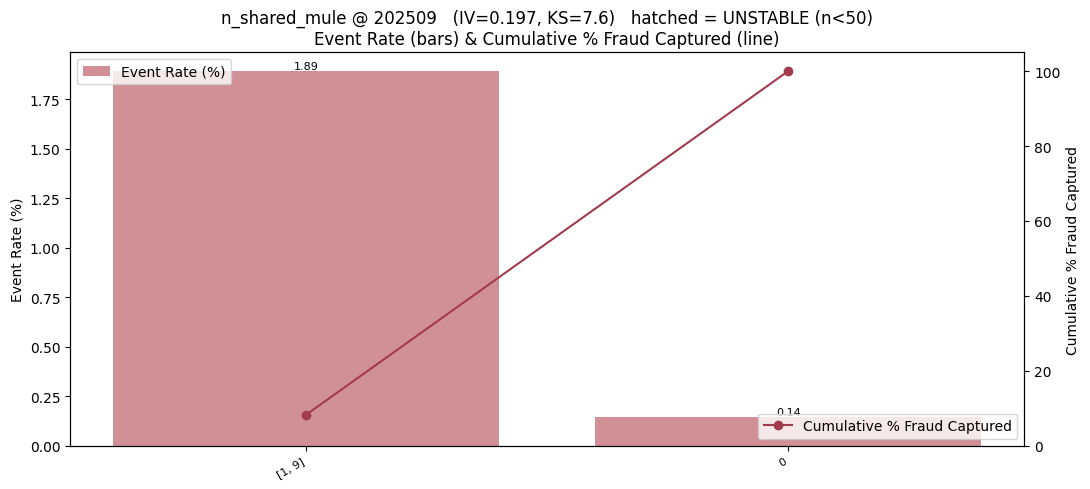

,bin,# frauds,# customers,event_rate_%,event_rate_LCB_%,cum_%_captured,stable
0,"[1, 9]",8,423,1.891,0.96,8.25,True
1,0,89,62174,0.143,0.12,100.00,True


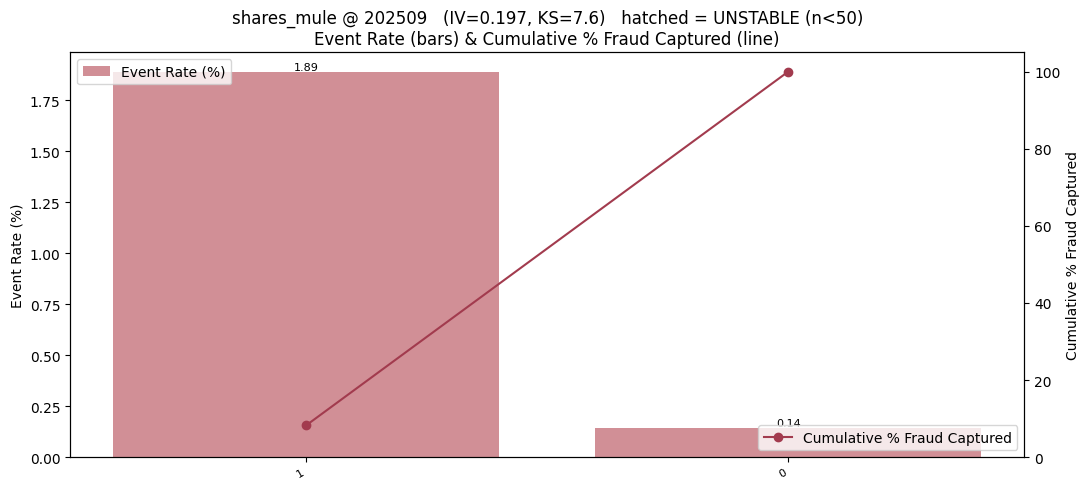

,bin,# frauds,# customers,event_rate_%,event_rate_LCB_%,cum_%_captured,stable
0,1,8,423,1.891,0.96,8.25,True
1,0,89,62174,0.143,0.12,100.00,True


[Stage 787:(22955 + -375) / 24000][Stage 788:(11947 + -13) / 12000][Stage 982:(11938 + -19) / 12000]

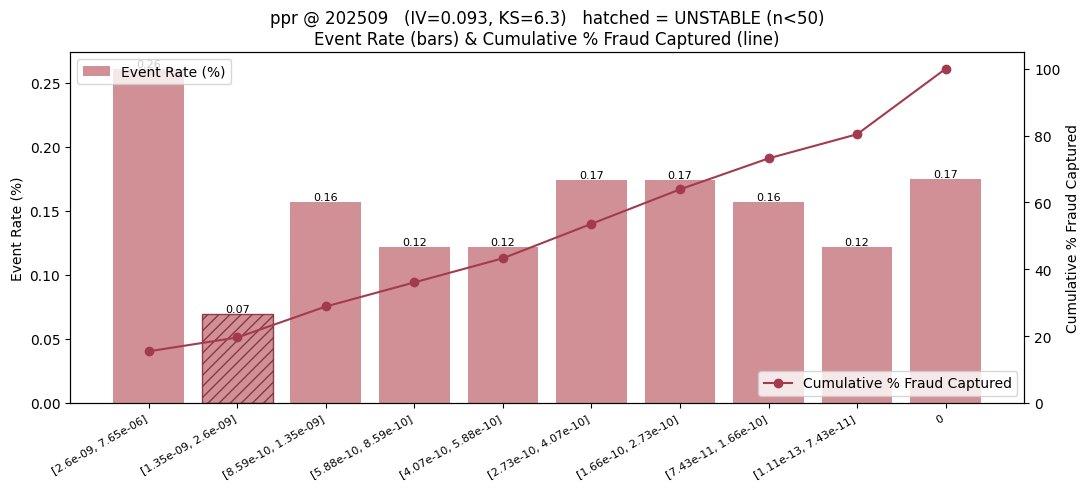

,bin,# frauds,# customers,event_rate_%,event_rate_LCB_%,cum_%_captured,stable
0,"[2.6e-09, 7.65e-06]",15,5748,0.261,0.16,15.46,True
1,"[1.35e-09, 2.6e-09]",4,5748,0.070,0.03,19.59,False
2,"[8.59e-10, 1.35e-09]",9,5747,0.157,0.08,28.87,True
3,"[5.88e-10, 8.59e-10]",7,5748,0.122,0.06,36.08,True
4,"[4.07e-10, 5.88e-10]",7,5747,0.122,0.06,43.30,True
5,"[2.73e-10, 4.07e-10]",10,5748,0.174,0.09,53.61,True
6,"[1.66e-10, 2.73e-10]",10,5747,0.174,0.09,63.92,True
7,"[7.43e-11, 1.66e-10]",9,5748,0.157,0.08,73.20,True
8,"[1.11e-13, 7.43e-11]",7,5748,0.122,0.06,80.41,True
9,0,19,10868,0.175,0.11,100.00,True


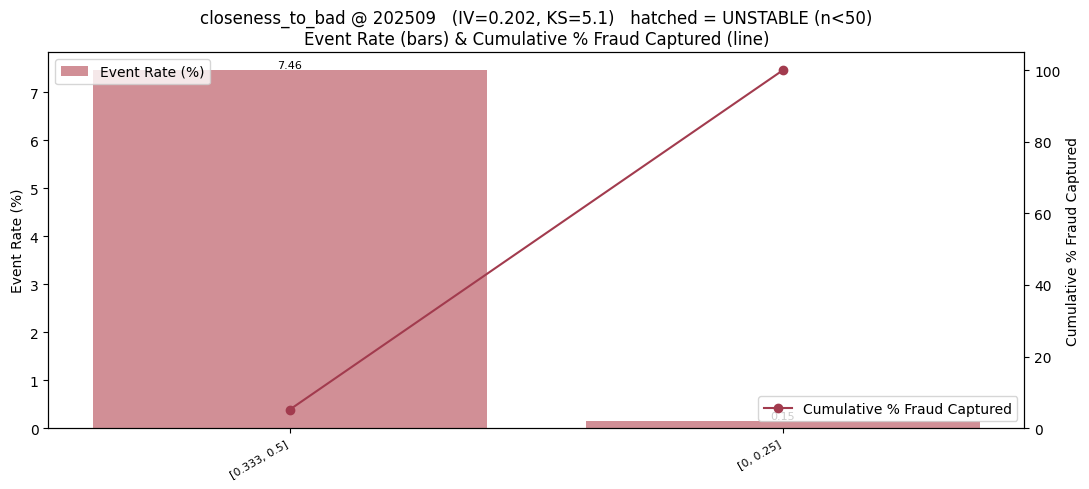

,bin,# frauds,# customers,event_rate_%,event_rate_LCB_%,cum_%_captured,stable
0,"[0.333, 0.5]",5,67,7.463,3.23,5.15,True
1,"[0, 0.25]",92,62530,0.147,0.12,100.00,True


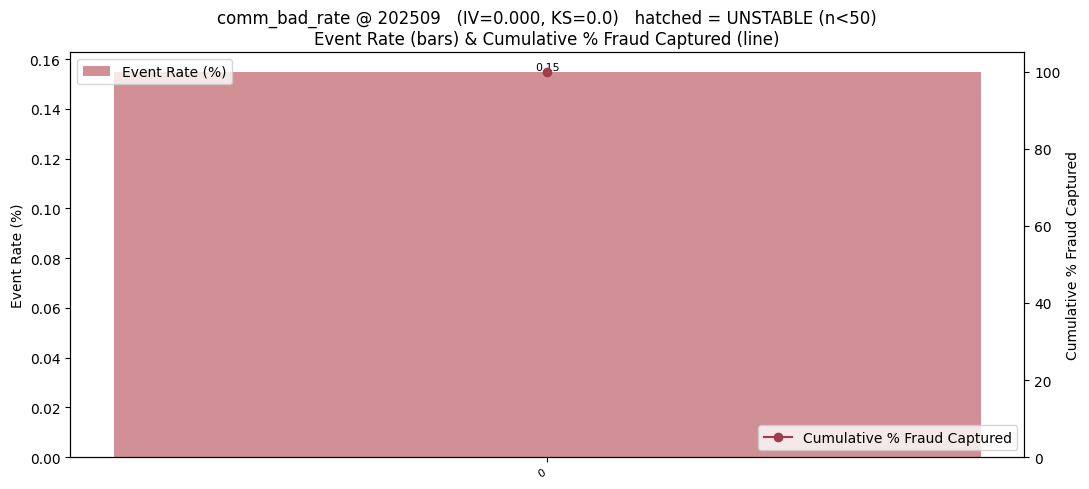

,bin,# frauds,# customers,event_rate_%,event_rate_LCB_%,cum_%_captured,stable
0,0,97,62597,0.155,0.13,100.0,True


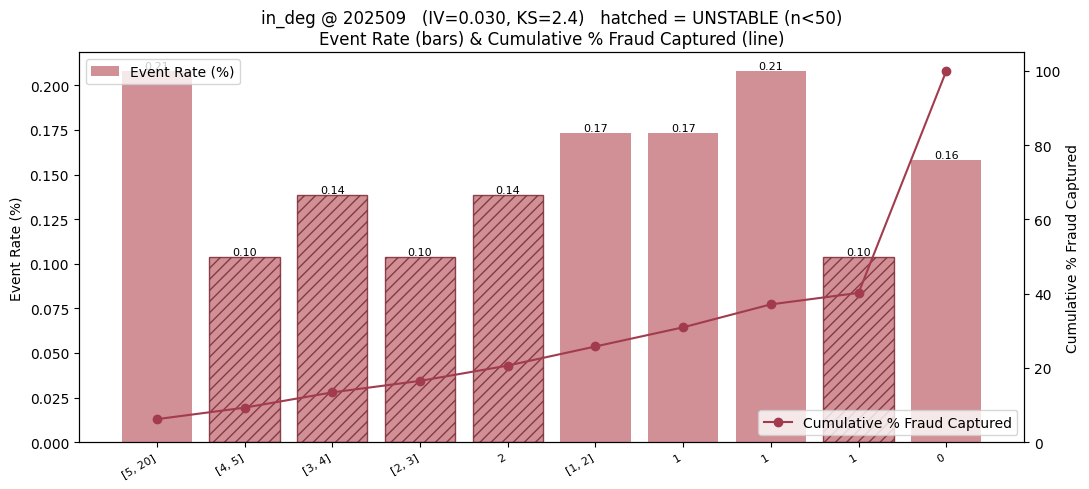

,bin,# frauds,# customers,event_rate_%,event_rate_LCB_%,cum_%_captured,stable
0,"[5, 20]",6,2884,0.208,0.10,6.19,True
1,"[4, 5]",3,2885,0.104,0.04,9.28,False
2,"[3, 4]",4,2883,0.139,0.05,13.40,False
3,"[2, 3]",3,2884,0.104,0.04,16.49,False
4,2,4,2884,0.139,0.05,20.62,False
5,"[1, 2]",5,2884,0.173,0.07,25.77,True
6,1,5,2884,0.173,0.07,30.93,True
7,1,6,2884,0.208,0.10,37.11,True
8,1,3,2885,0.104,0.04,40.21,False
9,0,58,36640,0.158,0.12,100.00,True


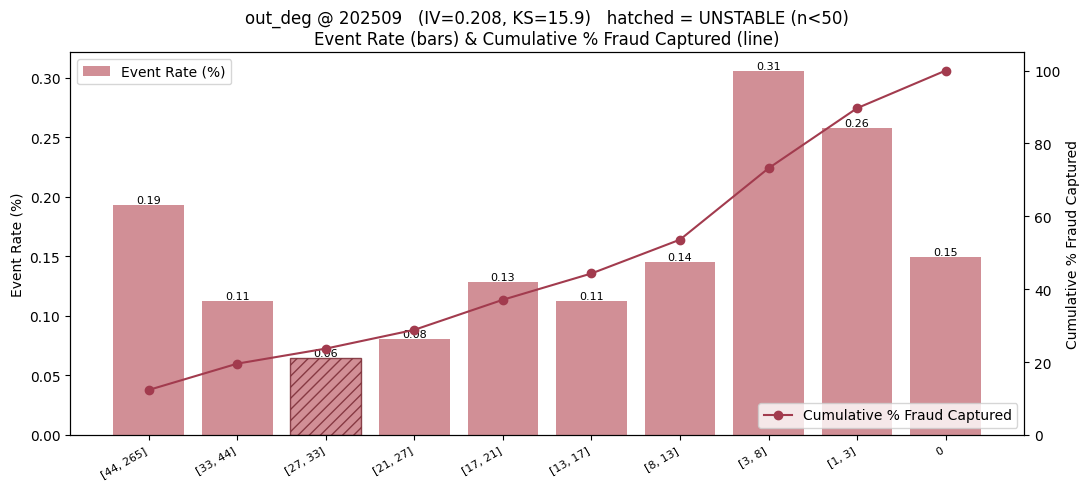

,bin,# frauds,# customers,event_rate_%,event_rate_LCB_%,cum_%_captured,stable
0,"[44, 265]",12,6211,0.193,0.11,12.37,True
1,"[33, 44]",7,6210,0.113,0.05,19.59,True
2,"[27, 33]",4,6210,0.064,0.03,23.71,False
3,"[21, 27]",5,6210,0.081,0.03,28.87,True
4,"[17, 21]",8,6210,0.129,0.07,37.11,True
5,"[13, 17]",7,6210,0.113,0.05,44.33,True
6,"[8, 13]",9,6210,0.145,0.08,53.61,True
7,"[3, 8]",19,6210,0.306,0.20,73.20,True
8,"[1, 3]",16,6211,0.258,0.16,89.69,True
9,0,10,6705,0.149,0.08,100.00,True


[Stage 787:(22955 + -375) / 24000][Stage 788:(11947 + -13) / 12000][Stage 982:(11938 + -19) / 12000]

In [17]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import IPython.display as _disp
from pyspark.sql import functions as _F

CUST_TBL      = "payment_cards_dev.TP99965073_v2_cust_features"
PLOT_FEATURES = ["n_shared_mule", "shares_mule", "ppr", "closeness_to_bad", "comm_bad_rate", "in_deg", "out_deg"]
PLOT_ANCHOR   = "202509"     # Sep = most matured; change to inspect another anchor
MIN_BIN_FRAC  = 0.01         # club any bin holding < 1% of customers into its neighbour
MIN_STABLE_CNT= 50           # bin with fewer customers than this is flagged UNSTABLE
MIN_STABLE_BAD= 5            # ...or fewer frauds than this
RISKY_ON_LEFT = True         # True = riskiest bin first (decile/gains look); False = feature-value order

def _wilson_lcb(bad, cnt, z=1.96):
    bad = np.asarray(bad, float); cnt = np.asarray(cnt, float)
    p = np.where(cnt > 0, bad / cnt, 0.0); denom = 1 + z*z/np.maximum(cnt, 1)
    centre = p + z*z/(2*np.maximum(cnt, 1)); margin = z*np.sqrt((p*(1-p) + z*z/(4*np.maximum(cnt,1)))/np.maximum(cnt,1))
    return np.where(cnt > 0, np.clip((centre - margin)/denom, 0, 1), 0.0)

def _robust_bins(x, max_bins=10):
    s = pd.Series(np.asarray(x, dtype=float)); nuniq = int(s.nunique(dropna=True))
    if nuniq <= 1: return np.zeros(len(s), dtype=int)
    if nuniq <= max_bins:
        order = {v: i for i, v in enumerate(sorted(s.dropna().unique()))}
        return s.map(order).fillna(0).astype(int).values
    z = (s == 0); out = np.zeros(len(s), dtype=int)
    if z.mean() >= 0.02 and int((~z).sum()) >= max_bins:
        pos = ~z
        qr = pd.qcut(s[pos].rank(method="first"), q=min(max_bins - 1, int((~z).sum())), labels=False, duplicates="drop")
        out[pos.values] = 1 + qr.astype(int).values; return out
    return pd.qcut(s.rank(method="first"), q=max_bins, labels=False, duplicates="drop").astype(int).values

def _club_sparse(d, n, min_frac):
    d = d.sort_index().copy()
    while len(d) > 2:
        share = d["cnt"] / n
        if share.min() >= min_frac: break
        j = int(share.values.argmin()); k = j + 1 if j == 0 else j - 1
        lo, hi = min(j, k), max(j, k)
        d.loc[d.index[lo], ["cnt", "bad"]] += d.loc[d.index[hi], ["cnt", "bad"]].values
        d.loc[d.index[lo], "hi"] = max(d.loc[d.index[lo], "hi"], d.loc[d.index[hi], "hi"])
        d.loc[d.index[lo], "lo"] = min(d.loc[d.index[lo], "lo"], d.loc[d.index[hi], "lo"])
        d = d.drop(d.index[hi]).reset_index(drop=True)
    return d

def _woe_iv(cnt, bad):
    good = cnt - bad; tb, tg = bad.sum(), good.sum()
    pb = (bad / tb).clip(lower=1e-6); pg = (good / tg).clip(lower=1e-6)
    return float(((pg - pb) * np.log(pg / pb)).sum())

_pdf = spark.table(CUST_TBL).where(_F.col("anchor_month") == PLOT_ANCHOR).select("target_fraud", *PLOT_FEATURES).toPandas()
_y = _pdf["target_fraud"].astype(int).values; _tot_bad = int(_y.sum()); _tot_good = len(_y) - _tot_bad
print("plotting anchor %s | customers=%d | frauds=%d" % (PLOT_ANCHOR, len(_pdf), _tot_bad))

def plot_sloping(feature):
    x = _pdf[feature].astype(float).values
    d = (pd.DataFrame({"b": _robust_bins(x), "x": x, "y": _y}).groupby("b")
         .agg(cnt=("y", "size"), bad=("y", "sum"), lo=("x", "min"), hi=("x", "max")).sort_index())
    d = _club_sparse(d, len(_pdf), MIN_BIN_FRAC)
    d = (d.iloc[::-1] if RISKY_ON_LEFT else d).reset_index(drop=True)
    d["event_rate_pct"] = 100.0 * d["bad"] / d["cnt"]
    cum_bad = d["bad"].cumsum(); cum_good = (d["cnt"] - d["bad"]).cumsum()
    d["pct_captured"] = 100.0 * cum_bad / max(_tot_bad, 1)
    ks = float((100.0 * cum_bad / max(_tot_bad, 1) - 100.0 * cum_good / max(_tot_good, 1)).abs().max())
    iv = _woe_iv(d["cnt"], d["bad"])
    d["er_lcb_pct"] = 100.0 * _wilson_lcb(d["bad"].values, d["cnt"].values)
    d["stable"] = (d["cnt"] >= MIN_STABLE_CNT) & (d["bad"] >= MIN_STABLE_BAD)
    labels = [("%.3g" % lo) if lo == hi else ("[%.3g, %.3g]" % (lo, hi)) for lo, hi in zip(d["lo"], d["hi"])]
    xs = range(len(d))
    fig, ax1 = plt.subplots(figsize=(11, 5))
    ax1.bar(xs, d["event_rate_pct"], color="#c97b84", alpha=0.85, label="Event Rate (%)")
    for i, v in enumerate(d["event_rate_pct"]): ax1.text(i, v, "%.2f" % v, ha="center", va="bottom", fontsize=8)
    ax1.set_ylabel("Event Rate (%)"); ax1.set_xticks(list(xs)); ax1.set_xticklabels(labels, rotation=30, ha="right", fontsize=8)
    for i, st in enumerate(d["stable"].values):
        if not st: ax1.patches[i].set_hatch("///"); ax1.patches[i].set_edgecolor("#7a2a34")
    ax2 = ax1.twinx()
    ax2.plot(xs, d["pct_captured"], color="#a23b4e", marker="o", label="Cumulative % Fraud Captured")
    ax2.set_ylabel("Cumulative % Fraud Captured"); ax2.set_ylim(0, 105)
    ax1.set_title("%s @ %s   (IV=%.3f, KS=%.1f)   hatched = UNSTABLE (n<%d)\nEvent Rate (bars) & Cumulative %% Fraud Captured (line)"
                  % (feature, PLOT_ANCHOR, iv, ks, MIN_STABLE_CNT), fontsize=12)
    ax1.legend(loc="upper left"); ax2.legend(loc="lower right"); fig.tight_layout(); plt.show()
    _disp.display(pd.DataFrame({"bin": labels, "# frauds": d["bad"].astype(int).values,
                                "# customers": d["cnt"].astype(int).values,
                                "event_rate_%": d["event_rate_pct"].round(3).values,
                                "event_rate_LCB_%": d["er_lcb_pct"].round(2).values,
                                "cum_%_captured": d["pct_captured"].round(2).values,
                                "stable": d["stable"].values}))

for _f in PLOT_FEATURES:
    try: plot_sloping(_f)
    except Exception as _e: print("  %s: skipped (%s)" % (_f, _e))
